In [29]:
!pip install -q transformers torch librosa datasets scikit-learn tqdm

In [30]:
import os
import numpy as np
import torch
import librosa
from tqdm import tqdm

from transformers import Wav2Vec2Processor, Wav2Vec2Model

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [31]:
DATA_PATH = "/content/drive/MyDrive/SER_Project/"
RAVDESS_FOLDERS = [DATA_PATH + "Ravdess_Song/", DATA_PATH + "Ravdess_Speech/"]
TESS_FOLDER = DATA_PATH + "Tess/"

In [32]:
EMOTION_LABELS = [
    "neutral", "calm", "happy", "sad",
    "angry", "fearful", "surprise", "disgust"
]

LABEL2IDX = {l:i for i,l in enumerate(EMOTION_LABELS)}

In [33]:
emotion_map_ravdess = {
    "01": "neutral","02": "calm","03": "happy","04": "sad",
    "05": "angry","06": "fearful","07": "disgust","08": "surprise",
}

emotion_map_tess = {
    "neutral":"neutral","happy":"happy","sad":"sad",
    "angry":"angry","fear":"fearful","disgust":"disgust",
    "pleasant_surprise":"surprise",
}

In [34]:
def load_audio(file_path, sr=16000, max_len=5):
    audio, _ = librosa.load(file_path, sr=sr)
    max_samples = sr * max_len

    if len(audio) < max_samples:
        audio = np.pad(audio, (0, max_samples - len(audio)))
    else:
        audio = audio[:max_samples]

    return audio

In [35]:
def load_ravdess(folder_list):
    X, y = [], []

    for base in folder_list:
        for actor in os.listdir(base):
            actor_path = os.path.join(base, actor)

            if os.path.isdir(actor_path):
                for file in os.listdir(actor_path):
                    if file.endswith(".wav"):
                        parts = file.split("-")
                        if len(parts) < 3:
                            continue

                        label = emotion_map_ravdess.get(parts[2])

                        if label in LABEL2IDX:
                            X.append(load_audio(os.path.join(actor_path, file)))
                            y.append(LABEL2IDX[label])

    return X, y


def load_tess(folder):
    X, y = [], []

    for root,_,files in os.walk(folder):
        for file in files:
            if file.endswith(".wav"):
                name = file.split("_")[-1].replace(".wav","").lower()
                label = emotion_map_tess.get(name)

                if label in LABEL2IDX:
                    X.append(load_audio(os.path.join(root,file)))
                    y.append(LABEL2IDX[label])

    return X, y

In [36]:
X_r, y_r = load_ravdess(RAVDESS_FOLDERS)
X_t, y_t = load_tess(TESS_FOLDER)

X = np.array(X_r + X_t, dtype=np.float32)
y = np.array(y_r + y_t)

print("Total:", len(X))

Total: 4852


In [37]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)

In [38]:
MODEL_ID = "jonatasgrosman/wav2vec2-large-xlsr-53-english"

processor = Wav2Vec2Processor.from_pretrained(MODEL_ID)
base_model = Wav2Vec2Model.from_pretrained(MODEL_ID)

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: jonatasgrosman/wav2vec2-large-xlsr-53-english
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 
lm_head.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [39]:
class SERDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        audio = self.X[idx]
        label = self.y[idx]

        inputs = processor(
            audio,
            sampling_rate=16000,
            return_tensors="pt",
            padding=True
        )

        return inputs.input_values.squeeze(0), torch.tensor(label)

In [40]:
train_ds = SERDataset(X_train, y_train)
val_ds = SERDataset(X_val, y_val)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=4)

In [45]:
class SERModel(nn.Module):
    def __init__(self, base_model, num_labels):
        super().__init__()
        self.wav2vec = base_model

        self.classifier = nn.Sequential(
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_labels)
        )

    def forward(self, x):
        x = self.wav2vec(x).last_hidden_state
        x = x.mean(dim=1)
        return self.classifier(x)

In [47]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SERModel(base_model, len(EMOTION_LABELS)).to(device)

In [48]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [49]:
EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for x, y in tqdm(train_loader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)

        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {total_loss:.4f}")

100%|██████████| 1092/1092 [16:34<00:00,  1.10it/s]


Epoch 1 Loss: 1149.0932


100%|██████████| 1092/1092 [16:31<00:00,  1.10it/s]


Epoch 2 Loss: 522.1473


100%|██████████| 1092/1092 [16:29<00:00,  1.10it/s]


...

Epoch 8 Loss: 122.6011


100%|██████████| 1092/1092 [16:32<00:00,  1.10it/s]


Epoch 9 Loss: 108.3298


100%|██████████| 1092/1092 [16:28<00:00,  1.10it/s]

Epoch 10 Loss: 118.5567


In [50]:
model.eval()

correct, total = 0, 0

with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(device), y.to(device)

        preds = model(x)
        preds = torch.argmax(preds, dim=1)

        correct += (preds == y).sum().item()
        total += y.size(0)

print("Accuracy:", correct / total)

Accuracy: 0.9382716049382716


In [51]:
y_true, y_pred = [], []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)

        out = model(x)
        pred = torch.argmax(out, dim=1).cpu().numpy()

        y_true.extend(y.numpy())
        y_pred.extend(pred)

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        59
           1       0.74      0.95      0.83        37
           2       0.96      0.88      0.92        78
           3       0.94      0.92      0.93        78
           4       0.95      0.97      0.96        78
           5       0.99      0.96      0.97        78
           6       0.90      0.95      0.92        19
           7       1.00      0.93      0.96        59

    accuracy                           0.94       486
   macro avg       0.93      0.94      0.93       486
weighted avg       0.94      0.94      0.94       486




===== CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

     neutral       0.95      0.95      0.95        59
        calm       0.74      0.95      0.83        37
       happy       0.96      0.88      0.92        78
         sad       0.94      0.92      0.93        78
       angry       0.95      0.97      0.96        78
     fearful       0.99      0.96      0.97        78
    surprise       0.90      0.95      0.92        19
     disgust       1.00      0.93      0.96        59

    accuracy                           0.94       486
   macro avg       0.93      0.94      0.93       486
weighted avg       0.94      0.94      0.94       486



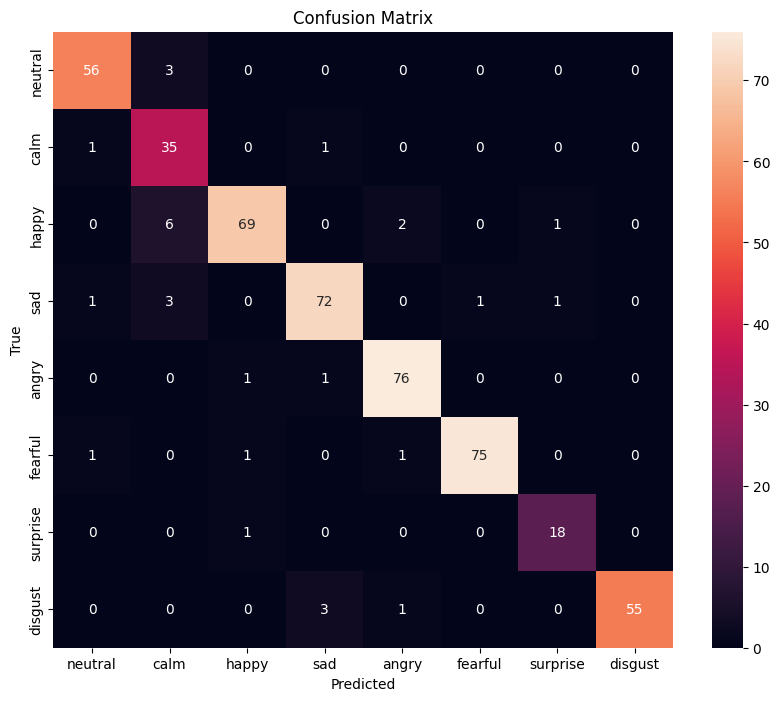

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)

        outputs = model(x)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        y_true.extend(y.numpy())
        y_pred.extend(preds)

# ================= REPORT =================
print("\n===== CLASSIFICATION REPORT =====\n")
print(classification_report(y_true, y_pred, target_names=EMOTION_LABELS))

# ================= CONFUSION MATRIX =================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=EMOTION_LABELS,
            yticklabels=EMOTION_LABELS)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()